<a href="https://colab.research.google.com/github/alexaK88/Q_jpeg_pennylane/blob/main/full_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 51.2 MB/s eta 0:00:00


# Full Workflow

This is the complete workflow.

## Import Libraries

In [2]:
import torch
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image
from itertools import product
from collections import Counter
from pennylane import numpy as pnp
from pennylane.templates import QFT
from skimage.transform import resize
from torch.nn.functional import relu
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from pennylane.templates import StronglyEntanglingLayers

## Load Data

In [3]:
# loading mnist from keras.datasets
from keras.datasets import mnist
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()
X = pnp.concatenate((X_train_full, X_test_full), axis=0)
y = pnp.concatenate((y_train_full, y_test_full), axis=0)

X = X.astype(pnp.uint8) # better to convert for binerization
y = y.astype(pnp.uint8)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X.shape, y.shape

((70000, 28, 28), (70000,))

## Data Preparation

We restrict the problem to binary classification, because kernel methods usually operate on binary labels (-1, +1).

In [5]:
# focus on binary classification
mask = (y == 4) | (y == 9)

X, y = X[mask], y[mask]

We limit the size of the dataset to `n_samples` because quantum kernel methods scale to approximately O(n^2) and anything more is just too computationally expensive. Also, QJPEG feature extraction is expensive.

In [6]:
n_samples = 100 # limit dataset size

X = X.values if hasattr(X, "values") else X # safer conversion with NumPy array format

X = X[:n_samples]
y = y[:n_samples]

Must convert labels to -1 and +1 for kernel methods.

In [7]:
print("Unique labels before encoding:", pnp.unique(y))
y = pnp.where(y == 4, -1, 1)
print("Unique labels after encoding:", pnp.unique(y))

Unique labels before encoding: [4 9]
Unique labels after encoding: [-1  1]


In [8]:
# Normalise pixels
X = X / 255.0
X = X.reshape(-1, 28, 28)

print(X.shape)
print("Pixel range:", X.min(), X.max())

(100, 28, 28)
Pixel range: 0.0 1.0


We reduce each image to 8x8:
8x8 = 64 = 2^6 -> 6 qubits

In [9]:
# convert each 28x28 binarised image to 8x8, then flatten to length 64
def to_8x8_vector(img_row):
    img_8x8 = resize(
        img_row,
        (8, 8),
        anti_aliasing=True, # smooths resizing
        preserve_range=True, # keeps pixel in [0, 1] range
        order=1 # bilinear interpolation
    )
    # flatten to vector for amplitude embedding
    img_8x8 = img_8x8.flatten().astype(float)
    # remove brightness bias
    img_8x8 = img_8x8 - img_8x8.mean()
    # normalize vector
    norm = pnp.linalg.norm(img_8x8)
    if norm > 0:
        img_8x8 /= norm
    else:
        # completely black image
        img_8x8[0] = 1.0
      # should be shape (64,)
    return img_8x8

# apply transformation to all images
X_8x8 = pnp.array([to_8x8_vector(x) for x in X], dtype=float)
X_8x8.shape

(100, 64)

###  QJPEG Compression

QJPEG:
- encode image as quantum amplitudes
- apply QFT
- discard qubits: remove high-frequency components
- reconstruct compressed representation

The idea is that we have lower resolution, but the structure is preserved.

In [10]:
def qjpeg_feature_extractor(img, n0, n2, shots):
    """
    Input: single image (28x28)
    Output: feature vector of size (2**n2,)
    """

    Cr, Cc = img.shape
    # --- vectorization ---
    states, norm = vectorization(img, Cr, Cc)

    # --- build circuit ---
    qcs = circuit_builder(states, n0, n2, shots)

    # --- run circuits ---
    out_freq = reconstruction(qcs, n2, norm)  # (num_patches, 2**n2)

    # --- compress patches (IMPORTANT) ---
    features = out_freq.mean(axis=0)  # (2**n2,)
    features = features / pnp.linalg.norm(features)

    # --- convert to tensor ---
    x = torch.tensor(features, dtype=torch.float32)

    # --- probabilities → amplitudes ---
    x = torch.sqrt(x + 1e-8)

    # --- normalize for amplitude embedding ---
    x = x / (torch.norm(x) + 1e-8)

    return x

def preprocess_for_qjpeg(img):
    img_resized = resize(
        img,
        (16, 16),
        anti_aliasing=True,
        preserve_range=True
    )
    return img_resized

def vectorization(img, Cr, Cc, renorm=False):
    "Vectorize the image into amplitude-encoding patches suitable for quantum circuits"
    # split the original image (Mr, Mc) into S equal-size patches of shape (Cr, Cc)
    Mr, Mc = img.shape
    patches = (img.reshape(Mc//Cr, Cr, -1, Cc).swapaxes(1, 2).reshape(-1, Cr, Cc))
    # 64 patches, (64, 64, 64) shape; S=64

    # vectorize each patch and collect all in a (N, Cr*Cc) array
    vect_patches = pnp.reshape(patches, (patches.shape[0], Cr * Cc)) # (64, 4096)

    # normalize each (Cr*Cc) vector to the intensity of the corresponding (Cr, Cc) patch
    states = pnp.zeros((patches.shape[0], Cr * Cc)) # (64, 4096)
    norm = pnp.zeros(patches.shape[0])

    for idx in range(patches.shape[0]): # for each patch
        # compute the sum of pixels intensities
        norm[idx] = vect_patches[idx].sum()
        if norm[idx] == 0:
            raise ValueError('Pixel value is 0')
        # normalize the patch vector so that its entries sum is 1
        tmp = vect_patches[idx] / norm[idx]
        # take the element-wise square root of the normalized vector
        states[idx] = pnp.sqrt(tmp)
    if renorm == False:
        norm = pnp.ones(patches.shape[0])
    # print(states[:10])

    return states, norm # amplitudes, pixek intensities' sums

def qft_swaps(wires):
    n = len(wires)
    # apply QFT to all qubits
    qml.QFT(wires=wires)
    # add swaps to reverse qubit order!
    for i in range(n // 2):
        qml.SWAP(wires=[wires[i], wires[n - i - 1]])


def iqft_swaps(wires):
    n = len(wires)
    # swaps again - BEFORE iqft
    for i in reversed(range(n // 2)):
        qml.SWAP(wires=[wires[i], wires[n-i-1]])
    qml.adjoint(QFT)(wires=wires)

def circuit_builder(states, n0, n2, shots):
    ntilde = (n0 - n2) // 2
    n1 = n0 - ntilde

    qnodes = []

    for idx in range(states.shape[0]):
        # qnode to capture current input state
        @qml.qnode(dev)
        def circuit():
            # print("State norm:", pnp.linalg.norm(states[idx]))
            # initializing the state (using AmplitudeEmbedding here, but I'm wondering if something else could work faster)
            qml.AmplitudeEmbedding(states[idx], wires=range(n0))

            # Hadamard on all n0 qubits
            for w in range(n0):
                qml.Hadamard(wires=w)

            # apply QFT on all qubits
            qft_swaps(wires=range(n0))

            # apply IQFT on first n1 qubits
            iqft_swaps(wires=range(n1))

            # setting boundaries - Rule 2
            discard_start = n0 // 2 - ntilde
            discard_end = n0 // 2 - 1
            discarded_qubits = set(range(discard_start, discard_end + 1))

            measured_qubits = [q for q in range(n1) if q not in discarded_qubits]

            # Hadamard on remaining qubits
            for q in measured_qubits:
                qml.Hadamard(wires=q)

            # print(f'Measured qubits: {measured_qubits}')

            return qml.probs(wires=measured_qubits)
        qnodes.append(circuit)

    return qnodes


def reconstruction(qnodes, n2, norm):
    out_freq = pnp.zeros((len(qnodes), 2 ** n2))
    for idx, qnode in enumerate(qnodes):
        probs = qnode()  # already a vector of length 2**n2
        # print(f"Circuit {idx} probs:", probs)
        out_freq[idx, :] = probs * norm[idx]
    return out_freq

def devectorization(out_freq):
    S = out_freq.shape[0]
    nrow = int(pnp.sqrt(out_freq.shape[1])) # rows per patch
    ncol = nrow

    decoded_patches = pnp.reshape(out_freq, (out_freq.shape[0], nrow, ncol)) # (S, nrow, ncol)

    im_h, im_w = nrow * int(pnp.sqrt(S)), ncol * int(pnp.sqrt(S)) # final shape

    # initialization
    decoded_img = pnp.zeros((im_w, im_h))

    idx = 0
    for row in pnp.arange(im_h - nrow + 1, step=nrow):
        for col in pnp.arange(im_w - ncol + 1, step=ncol):
            decoded_img[row:row+nrow, col:col+ncol] = decoded_patches[idx]
            idx += 1

    return decoded_img

### Train/test Split

In [11]:
idx = pnp.arange(n_samples)

idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

In [12]:
n0 = 8  # since 16x16 = 256 = 2^8
n2 = 6  # output dimension = 64 -> matches kernel (4x reduction)
shots = 2000

# define device with n0 qubits
dev = qml.device("default.qubit", wires=n0, shots=shots)

# extract features
X_train_qjpeg = []
X_test_qjpeg = []

print("Extracting QJPEG features (train)...")
for i in range(len(idx_train)):
    img = preprocess_for_qjpeg(X[idx_train[i]])
    feat = qjpeg_feature_extractor(img, n0=n0, n2=n2, shots=shots)
    X_train_qjpeg.append(feat)

print("Extracting QJPEG features (test)...")
for i in range(len(idx_test)):
    img = preprocess_for_qjpeg(X[idx_test[i]])
    feat = qjpeg_feature_extractor(img, n0=n0, n2=n2, shots=shots)
    X_test_qjpeg.append(feat)

X_train_qjpeg = torch.stack(X_train_qjpeg).float()
X_test_qjpeg  = torch.stack(X_test_qjpeg).float()

/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Extracting QJPEG features (train)...
Extracting QJPEG features (test)...


In [13]:
# sanity check, make sure no NaNs exist and all vectors are normalised, i.e. norm is around 1
print("Any NaNs?", pnp.isnan(X_8x8).any())
print("Norm check:", pnp.min(pnp.linalg.norm(X_8x8, axis=1)), pnp.max(pnp.linalg.norm(X_8x8, axis=1)))

Any NaNs? False
Norm check: 0.9999999999999998 1.0


In [14]:
X_train = X_8x8[idx_train]
X_test  = X_8x8[idx_test]

## QEK definition

In [15]:
n_qubits = 6
dev_ideal = qml.device('default.qubit', wires=n_qubits)

In [16]:
# -----------------------------
# Quantum circuit components
# -----------------------------
# def qek_layer_amplitude(x, theta):
#     # Data re-uploading via phase gates (breaks kernel symmetry)
#     wires = range(n_qubits)
#
#     qml.AmplitudeEmbedding(
#         x,
#         wires=range(n_qubits),
#         normalize=True
#     )
#     for l in range(theta.shape[0]):
#         # for j, wire in enumerate(wires):
#         #     qml.Hadamard(wires=wire)
#         for j, wire in enumerate(wires):
#             # qml.RY(theta[l, j, 0], wires=wire)
#             qml.CRZ(theta[l, j, 0], wires=[j, (j+1) % n_qubits])
#
#         # for j, wire in enumerate(wires):
#         #     qml.RX(theta[l, j, 1], wires=wire)
#         #     qml.RY(theta[l, j, 2], wires=wire)
#
#     # qml.StronglyEntanglingLayers(theta, wires=wires)

def qek_layer_amplitude(x, theta):
    wires = range(n_qubits)

    qml.AmplitudeEmbedding(x, wires=wires, normalize=True)

    for l in range(theta.shape[0]):

        # smooth local control
        for j in wires:
            qml.RY(theta[l, j, 0], wires=j)
            qml.RZ(theta[l, j, 1], wires=j)

        # light entanglement
        for j in range(n_qubits - 1):
            qml.CZ(wires=[j, j+1])
            qml.CZ(wires=[j, (j+2) % n_qubits])


# -----------------------------
# Quantum kernel QNode
# -----------------------------
@qml.qnode(dev_ideal, interface="torch", diff_method="backprop")
def qek_kernel(x1, x2, theta, n_qubits):
    """Adjoint-based kernel: |<phi(x1)|phi(x2)>|^2."""
    qek_layer_amplitude(x1, theta)
    qml.adjoint(qek_layer_amplitude)(x2, theta)
    return qml.expval(qml.Projector([0]*n_qubits, wires=range(n_qubits)))


def split_indices(N, block_size):
    """Return a list of index blocks for M-SPLIT."""
    blocks = []
    for start in range(0, N, block_size):
        end = min(start + block_size, N)
        blocks.append(pnp.arange(start, end))
    return blocks

def compute_block_kernel(X, theta, block_idx, n_qubits):
    """Compute PSD-corrected kernel block."""
    X_block = X[block_idx]
    n = len(block_idx)
    K_block = torch.zeros((n, n), dtype=X_block.dtype, device=X_block.device)

    for i in range(n):
        for j in range(i, n):
            val = qek_kernel(X_block[i], X_block[j], theta, n_qubits)
            K_block[i, j] = val.to(torch.float32)
            K_block[j, i] = val.to(torch.float32)

    # PSD projection
    K_block_np = K_block.detach().numpy()
    eigvals, eigvecs = pnp.linalg.eigh(K_block_np)
    eigvals[eigvals < 0] = 0
    K_block_psd = torch.tensor(eigvecs @ pnp.diag(eigvals) @ eigvecs.T, dtype=X_block.dtype)

    # Normalize diagonals to 1
    diag = torch.sqrt(torch.diag(K_block_psd))
    K_block_psd /= diag[:, None]
    K_block_psd /= diag[None, :]

    return K_block_psd

def kernel_matrix(X, theta):
    n = len(X)
    K = torch.zeros((n, n), dtype=torch.float32)

    for i in range(n):
        for j in range(i, n):
            val = qek_kernel(X[i], X[j], theta, 6)

            K[i, j] = val
            K[j, i] = val

    return K


def msplit_kernel(X, theta, n_qubits, block_size=10):
    N = len(X)
    blocks = split_indices(N, block_size)
    K = torch.zeros((N, N), dtype=torch.float32)

    # Compute each block independently
    for block in blocks:
        K_block = compute_block_kernel(X, theta, block, n_qubits)
        idx = pnp.ix_(block, block)
        K[idx] = K_block

    return K

# -----------------------------
# Minibatch kernel matrix
# -----------------------------
def kernel_matrix_minibatch(X_batch, theta, n_qubits):
    """Compute symmetric kernel matrix for a minibatch."""
    n = X_batch.shape[0]
    K = torch.zeros((n, n), dtype=X_batch.dtype)
    for i in range(n):
        for j in range(i, n):
            val = qek_kernel(X_batch[i], X_batch[j], theta, n_qubits)
            K[i, j] = val
            K[j, i] = val
    return K

# -----------------------------
# Hinge loss for SVM
# -----------------------------
def hinge_loss_kernel(K, y, alpha):
    """Squared hinge loss with dual variables alpha."""
    preds = K @ (alpha * y)
    return torch.mean(relu(1 - y * preds) ** 2)

def kernel_target_alignment(K, y, eps=1e-8):
    y = y.view(-1,1)
    K_star = y @ y.T

    num = torch.sum(K * K_star)
    den = torch.sqrt(torch.sum(K**2) + eps) * torch.sqrt(torch.sum(K_star**2) + eps)

    return num / den

def compute_block_kernel_train(X, theta, block_idx, n_qubits):
    """Differentiable kernel block (no PSD projection)."""

    X_block = X[block_idx]
    n = len(block_idx)

    # Collect values to avoid in-place operations
    kernel_values_rows = []
    for i in range(n):
        row_values = []
        for j in range(n):
            if j < i:
                # Leverage symmetry to avoid recomputing
                row_values.append(kernel_values_rows[j][i])
            else:
                val = qek_kernel(X_block[i], X_block[j], theta, n_qubits)
                row_values.append(val.to(torch.float32))
        kernel_values_rows.append(row_values)

    # Stack the collected tensor values to form K_block
    K_block = torch.stack([torch.stack(row) for row in kernel_values_rows])

    return K_block

def center_kernel(K):
    n = K.shape[0]
    one = torch.ones((n, n), dtype=K.dtype, device=K.device) / n
    return K - one @ K - K @ one + one @ K @ one


def msplit_kernel_train(X, theta, n_qubits, block_size=10):
    N = len(X)
    blocks = split_indices(N, block_size)
    K = torch.zeros((N, N), dtype=torch.float32) # K here does not need requires_grad=True if filled by gradient-tracking tensors

    # Compute each block independently
    for block in blocks:
        K_block = compute_block_kernel_train(X, theta, block, n_qubits) # Call the differentiable version
        idx = pnp.ix_(block, block)
        K[idx] = K_block

    return K


def quantum_kernel_train_kta(
    X_train, y_train, n_qubits,
    n_layers=2, steps=150, batch_size=None,
    lr=0.001, block_size=4, verbose=True,
    max_grad_norm=1.0, use_full_batch=False
):
    """
    Stable QEK training with KTA smoothing and safe backprop.

    Args:
        X_train, y_train : training data
        n_qubits : number of qubits in circuit
        n_layers : variational layers
        steps : optimization steps
        batch_size : minibatch size (ignored if use_full_batch=True)
        lr : learning rate
        block_size : for block kernel computation
        verbose : print KTA every 5 steps
        max_grad_norm : gradient clipping
        use_full_batch : if True, compute kernel on full dataset for smoother KTA
    """
    X_train = torch.as_tensor(X_train, dtype=torch.float32)
    y_train = torch.as_tensor(y_train, dtype=torch.float32)

    N = len(X_train)
    theta = torch.randn(n_layers, n_qubits, 3, requires_grad=True)
    optimizer = torch.optim.Adam([theta], lr=lr)

    kta_history = []
    alignment_smooth = None  # for logging only

    for step in range(steps):
        optimizer.zero_grad()

        # --- minibatch or full-batch ---
        if use_full_batch or batch_size is None:
            Xb, yb = X_train, y_train
        else:
            idx = pnp.random.choice(N, batch_size, replace=False)
            Xb, yb = X_train[idx], y_train[idx]

        # Compute differentiable kernel
        Kb = msplit_kernel_train(Xb, theta, n_qubits, block_size)
        Kc = center_kernel(Kb)

        # --- kernel-target alignment ---
        alignment = kernel_target_alignment(Kc, yb)

        # Backprop through current alignment only
        loss = -alignment
        loss.backward()

        # --- gradient clipping ---
        torch.nn.utils.clip_grad_norm_([theta], max_grad_norm)
        optimizer.step()

        # --- KTA smoothing for logging only ---
        if alignment_smooth is None:
            alignment_smooth = alignment.detach()
        else:
            alignment_smooth = 0.9 * alignment_smooth + 0.1 * alignment.detach()

        kta_history.append(alignment.item())

        if verbose and step % 5 == 0:
            print(f"Step {step:03d} | KTA = {alignment_smooth.item():.4f}")

    return theta, kta_history


/usr/local/lib/python3.12/dist-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains tensors of types {'autograd', 'torch'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


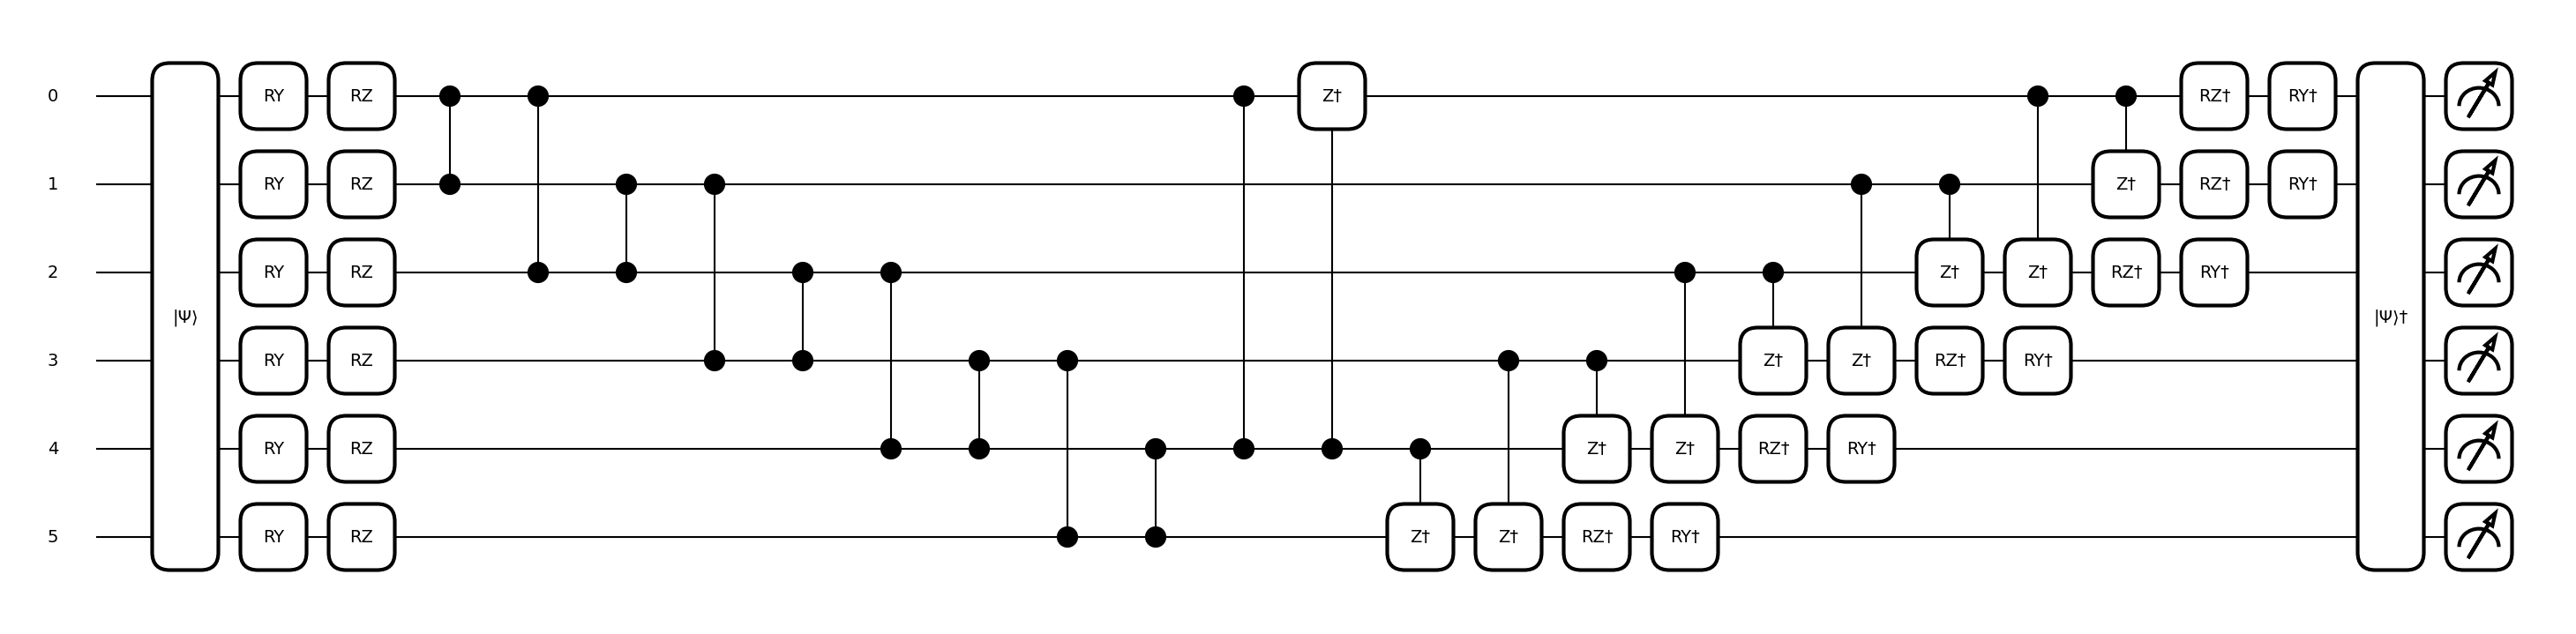

In [17]:
# visualizing the circuit

theta = torch.randn(1, n_qubits, 3, requires_grad=True)
fig, ax = qml.draw_mpl(qek_kernel)(X_train[0], X_train[0], theta, n_qubits)
fig.show()

## Training Theta

In [18]:
batch_size = 80
steps = 100

In [19]:
# --- Ensure all datasets are proper 2D PyTorch tensors ---
import torch
import numpy as pnp

# Convert 8x8 downsampled images
X_train = torch.tensor(pnp.array(X_train), dtype=torch.float32)
X_test  = torch.tensor(pnp.array(X_test), dtype=torch.float32)

# QJPEG features are already tensors, just make sure dtype is float32
X_train_qjpeg = X_train_qjpeg.float()
X_test_qjpeg  = X_test_qjpeg.float()

# Labels should be tensors of type float32
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
theta_1, loss_history_1 = quantum_kernel_train_kta(
    X_train,
    y_train,
    n_qubits=n_qubits,
    n_layers=1,
    steps=steps,
    batch_size=batch_size
)

Step 000 | KTA = 0.1172
Step 005 | KTA = 0.1092
Step 010 | KTA = 0.1061
Step 015 | KTA = 0.1015
Step 020 | KTA = 0.1008
Step 025 | KTA = 0.0999


In [ ]:
theta_1_qjpeg, loss_history_1_qjpeg = quantum_kernel_train_kta(
    X_train_qjpeg,
    y_train,
    n_qubits=n_qubits,
    n_layers=1,
    steps=steps,
    batch_size=batch_size
)

In [ ]:
theta_2, loss_history_2 = quantum_kernel_train_kta(
    X_train,
    y_train,
    n_qubits=n_qubits,
    n_layers=2,
    steps=steps,
    batch_size=batch_size
)

In [ ]:
theta_2_qjpeg, loss_history_2_qjpeg = quantum_kernel_train_kta(
    X_train_qjpeg,
    y_train,
    n_qubits=n_qubits,
    n_layers=2,
    steps=steps,
    batch_size=batch_size
)

In [ ]:
theta_4, loss_history_4 = quantum_kernel_train_kta(
    X_train,
    y_train,
    n_qubits = n_qubits,
    n_layers = 4,
    steps = steps,
    batch_size = batch_size
)

In [ ]:
theta_4_qjpeg, loss_history_4_qjpeg = quantum_kernel_train_kta(
    X_train_qjpeg,
    y_train,
    n_qubits = n_qubits,
    n_layers = 4,
    steps = steps,
    batch_size = batch_size
)

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(loss_history_1, label="1 layer")
# plt.plot(loss_history_1_qjpeg, label="1 layer (QJPEG)")
# plt.plot(loss_history_2, label="2 layers")
# plt.plot(loss_history_2_qjpeg, label="2 layers (QJPEG)")
# plt.plot(loss_history_4, label="4 layers")
# plt.plot(loss_history_4_qjpeg, label="4 layers (QJPEG)")

plt.xlabel("Training step")
plt.ylabel("KTA")
plt.title("KTA Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def smooth(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(8,5))
# plt.plot(smooth(loss_history_1), label="1 layer")
plt.plot(smooth(loss_history_1_qjpeg), label="1 layer (QJPEG)")
# plt.plot(smooth(loss_history_2), label="2 layers")
plt.plot(smooth(loss_history_2_qjpeg), label="2 layers (QJPEG)")
# plt.plot(smooth(loss_history_4), label="4 layers")
plt.plot(smooth(loss_history_4_qjpeg), label="4 layers (QJPEG)")

plt.xlabel("Training step")
plt.ylabel("Smoothed KTA")
plt.title("Smoothed KTA")
plt.legend()
plt.grif=True

plt.show()

In [ ]:
def running_mean(x):
    return np.cumsum(x) / np.arange(1, len(x) + 1)

plt.figure(figsize=(8,5))

plt.plot(running_mean(loss_history_1), label="1 layer")
plt.plot(running_mean(loss_history_1_qjpeg), label="1 layer QJPEG")

plt.plot(running_mean(loss_history_2), label="2 layers")
plt.plot(running_mean(loss_history_2_qjpeg), label="2 layers QJPEG")
plt.plot(running_mean(loss_history_4), label="4 layers")
plt.plot(running_mean(loss_history_4_qjpeg), label="4 layers QJPEG")

plt.xlabel("Training step")
plt.ylabel("Running mean ")
plt.title("Running average")

plt.legend()
plt.grid(True)

plt.show()

## Classification

In [ ]:
K_train = msplit_kernel(X_train, theta_1, n_qubits, block_size=12)
K_train_qjpeg = msplit_kernel(X_train_qjpeg, theta_1_qjpeg, n_qubits, block_size=12)

In [ ]:
from sklearn.svm import SVC


K_train_np = K_train.detach().numpy()

clf = SVC(kernel='precomputed')
clf.fit(K_train_np, y_train)

# Compute test kernel
K_test_np = np.array([[qek_kernel(x1, x2, theta_1, n_qubits).item()
                       for x2 in X_train] for x1 in X_test])

y_pred = clf.predict(K_test_np)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
K_train_np_qjpeg = K_train_qjpeg.detach().numpy()

clf = SVC(kernel='precomputed')
clf.fit(K_train_np_qjpeg, y_train)

# Compute test kernel
K_test_np_qjpeg = np.array([[qek_kernel(x1, x2, theta_1_qjpeg, n_qubits).item()
                       for x2 in X_train_qjpeg] for x1 in X_test_qjpeg])

y_pred_qjpeg = clf.predict(K_test_np_qjpeg)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred_qjpeg))

In [ ]:
K_train_4 = msplit_kernel(X_train, theta_4, n_qubits, block_size=12)
K_train_qjpeg_4 = msplit_kernel(X_train_qjpeg, theta_4_qjpeg, n_qubits, block_size=12)

In [ ]:
K_train_np_4 = K_train_4.detach().numpy()

clf = SVC(kernel='precomputed')
clf.fit(K_train_np_4, y_train)

# Compute test kernel
K_test_np_4 = np.array([[qek_kernel(x1, x2, theta_4, n_qubits).item()
                       for x2 in X_train] for x1 in X_test])

y_pred_4 = clf.predict(K_test_np_4)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred_4))

In [ ]:
K_train_np_4_qjpeg = K_train_qjpeg_4.detach().numpy()

clf = SVC(kernel='precomputed')
clf.fit(K_train_np_4_qjpeg, y_train)

# Compute test kernel
K_test_np_4_qjpeg = np.array([[qek_kernel(x1, x2, theta_4_qjpeg, n_qubits).item()
                       for x2 in X_train_qjpeg] for x1 in X_test_qjpeg])

y_pred_4_qjpeg = clf.predict(K_test_np_4_qjpeg)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred_4_qjpeg))